In [2]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.data.storage.database import get_engine

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

engine = get_engine()
print("Connected.")

Connected.


In [10]:
with engine.connect() as conn:
    prices = pd.read_sql("""
        SELECT p.date, p.close, p.adjusted_close, p.volume,
               p.day_low, p.day_high, s.ticker, s.sector, s.security_type
        FROM prices p
        JOIN securities s ON p.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND p.close IS NOT NULL
    """, conn)

    returns = pd.read_sql("""
        SELECT r.date, r.adj_daily_return, s.ticker, s.sector
        FROM returns r
        JOIN securities s ON r.security_id = s.security_id
        WHERE s.security_type = 'equity'
        AND r.adj_daily_return IS NOT NULL
        AND ABS(r.adj_daily_return) <= 1.0
    """, conn)

    indices = pd.read_sql("""
        SELECT date, nse_20, nse_25, nse_all_share
        FROM indices
        WHERE nse_20 IS NOT NULL
        ORDER BY date
    """, conn)

prices['date'] = pd.to_datetime(prices['date'])
returns['date'] = pd.to_datetime(returns['date'])
indices['date'] = pd.to_datetime(indices['date'])

print(f"Prices:  {len(prices):,} rows, {prices['ticker'].nunique()} stocks")
print(f"Returns: {len(returns):,} rows")
print(f"Date range: {prices['date'].min().date()} to {prices['date'].max().date()}")

Prices:  280,718 rows, 85 stocks
Returns: 249,488 rows
Date range: 2007-01-02 to 2025-10-31


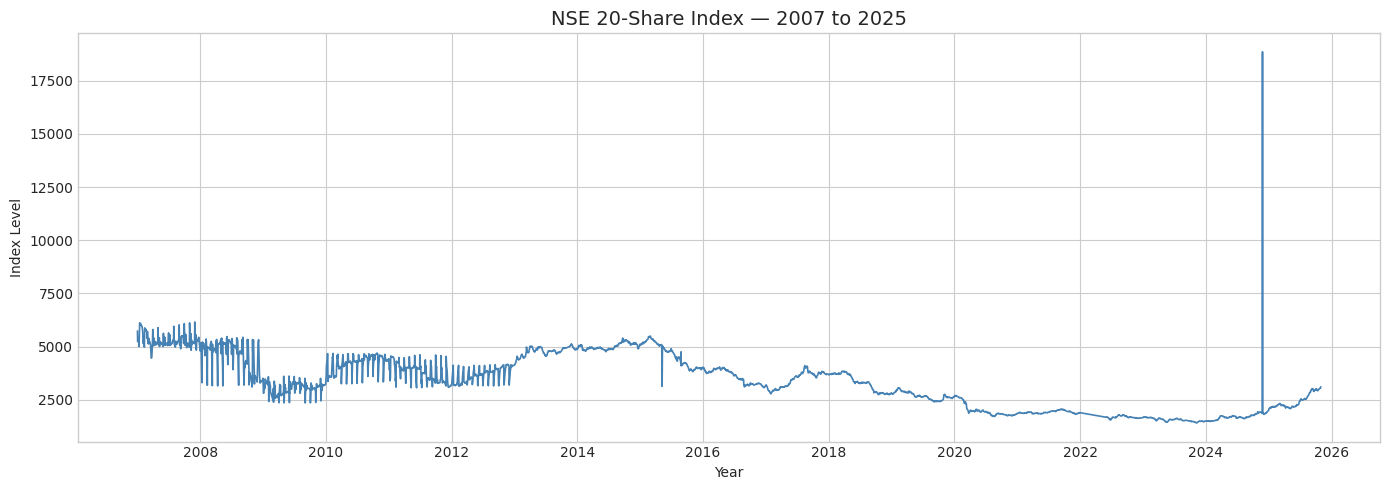

Start: 5739.05
End:   3116.69
Total return: -45.7%


In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

dates = indices['date'].values
values = indices['nse_20'].values

ax.plot(dates, values, color='steelblue', lw=1.2)
ax.set_title('NSE 20-Share Index — 2007 to 2025', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Index Level')
plt.tight_layout()
plt.show()

start = float(indices['nse_20'].iloc[0])
end = float(indices['nse_20'].iloc[-1])
print(f"Start: {start:.2f}")
print(f"End:   {end:.2f}")
print(f"Total return: {(end/start - 1)*100:.1f}%")

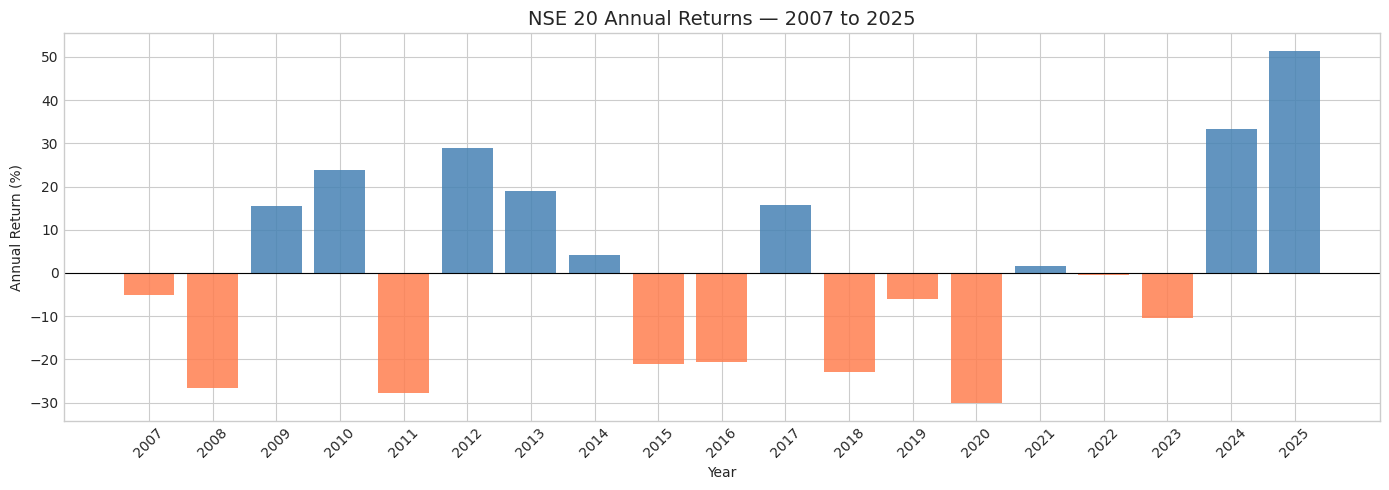

Annual returns:
  2007:   -5.1%  -█
  2008:  -26.6%  -████████
  2009:  +15.4%  +█████
  2010:  +23.8%  +███████
  2011:  -27.7%  -█████████
  2012:  +29.0%  +█████████
  2013:  +19.0%  +██████
  2014:   +4.1%  +█
  2015:  -21.0%  -███████
  2016:  -20.5%  -██████
  2017:  +15.8%  +█████
  2018:  -22.9%  -███████
  2019:   -6.0%  -█
  2020:  -30.1%  -██████████
  2021:   +1.6%  +
  2022:   -0.6%  -
  2023:  -10.4%  -███
  2024:  +33.3%  +███████████
  2025:  +51.4%  +█████████████████


In [12]:
# Annual index returns
indices['year'] = indices['date'].dt.year
annual = indices.groupby('year').agg(
    start=('nse_20', 'first'),
    end=('nse_20', 'last')
).reset_index()
annual['return_pct'] = (annual['end'] / annual['start'] - 1) * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if r >= 0 else 'coral' for r in annual['return_pct']]
ax.bar(annual['year'], annual['return_pct'], color=colors, alpha=0.85)
ax.axhline(y=0, color='black', lw=0.8)
ax.set_title('NSE 20 Annual Returns — 2007 to 2025', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Return (%)')
ax.set_xticks(annual['year'])
ax.set_xticklabels(annual['year'], rotation=45)
plt.tight_layout()
plt.show()

print("Annual returns:")
for _, row in annual.iterrows():
    bar = '█' * int(abs(row['return_pct']) / 3)
    sign = '+' if row['return_pct'] >= 0 else '-'
    print(f"  {int(row['year'])}: {row['return_pct']:+6.1f}%  {sign}{bar}")

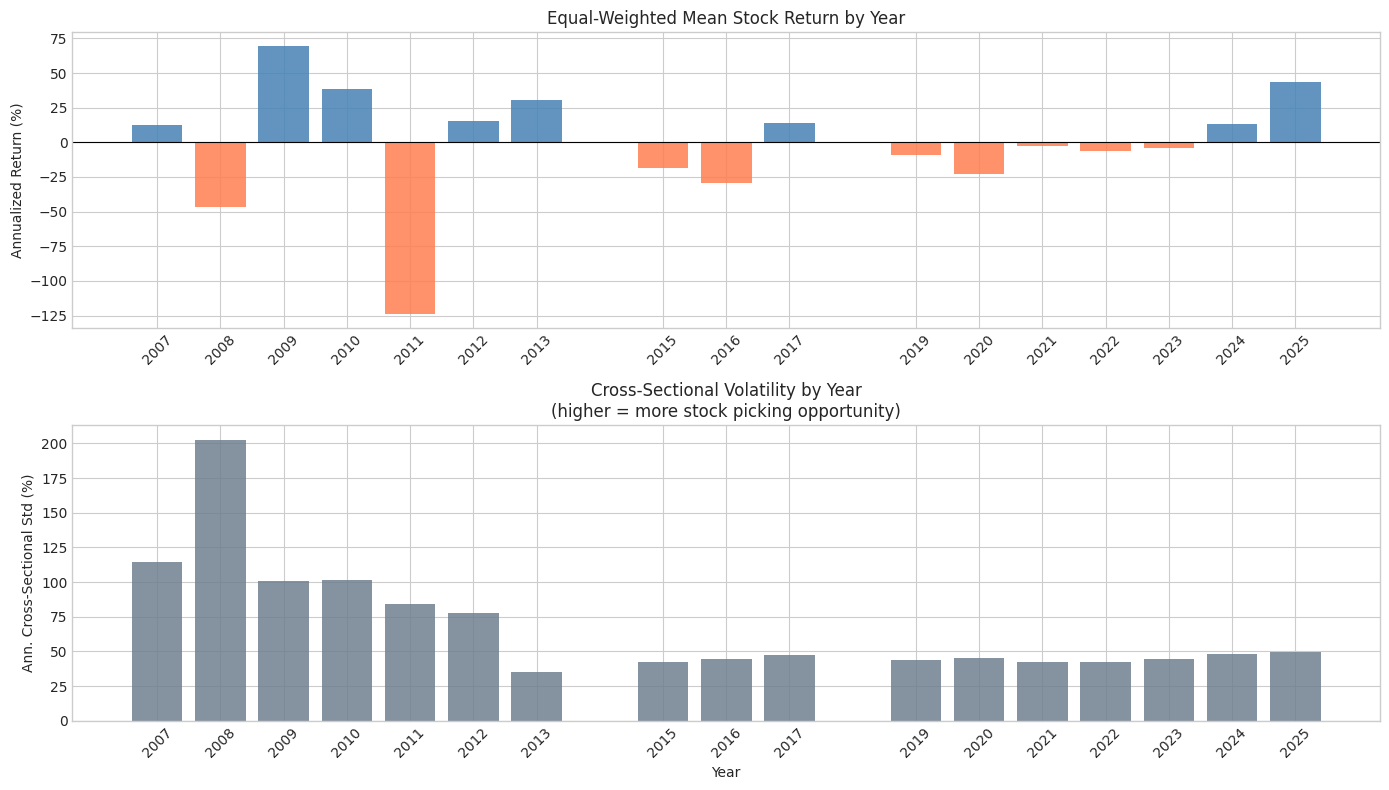


Year  | Mkt Return | Cross-Sec Std | Sharpe
------------------------------------------------
  2007  |    +12.5%  |      114.8%    | +0.109
  2008  |    -47.0%  |      202.8%    | -0.232
  2009  |    +69.7%  |      100.9%    | +0.690
  2010  |    +38.7%  |      101.6%    | +0.381
  2011  |   -124.1%  |       84.2%    | -1.473
  2012  |    +15.2%  |       78.0%    | +0.195
  2013  |    +30.3%  |       35.4%    | +0.856
  2015  |    -18.6%  |       42.7%    | -0.437
  2016  |    -29.2%  |       44.8%    | -0.651
  2017  |    +14.1%  |       47.7%    | +0.295
  2019  |     -9.2%  |       43.5%    | -0.212
  2020  |    -23.2%  |       45.5%    | -0.510
  2021  |     -2.6%  |       42.2%    | -0.061
  2022  |     -6.4%  |       42.7%    | -0.151
  2023  |     -4.3%  |       44.7%    | -0.096
  2024  |    +13.1%  |       48.1%    | +0.272
  2025  |    +43.9%  |       49.4%    | +0.888


In [13]:
# Cross-sectional dispersion — opportunity for stock selection
returns['year'] = returns['date'].dt.year

dispersion = returns.groupby('year')['adj_daily_return'].agg(
    mean_return=lambda x: x.mean() * 252 * 100,
    cross_sec_std=lambda x: x.std() * np.sqrt(252) * 100,
    sharpe=lambda x: (x.mean() / x.std() * np.sqrt(252)) if x.std() > 0 else 0
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Mean annual return by year
ax = axes[0]
colors = ['steelblue' if r >= 0 else 'coral' for r in dispersion['mean_return']]
ax.bar(dispersion['year'], dispersion['mean_return'], color=colors, alpha=0.85)
ax.axhline(y=0, color='black', lw=0.8)
ax.set_title('Equal-Weighted Mean Stock Return by Year', fontsize=12)
ax.set_ylabel('Annualized Return (%)')

# Cross-sectional volatility — stock picking opportunity
ax = axes[1]
ax.bar(dispersion['year'], dispersion['cross_sec_std'], 
       color='slategray', alpha=0.85)
ax.set_title('Cross-Sectional Volatility by Year\n(higher = more stock picking opportunity)', fontsize=12)
ax.set_ylabel('Ann. Cross-Sectional Std (%)')
ax.set_xlabel('Year')

for ax in axes:
    ax.set_xticks(dispersion['year'])
    ax.set_xticklabels(dispersion['year'], rotation=45)

plt.tight_layout()
plt.show()

print("\nYear  | Mkt Return | Cross-Sec Std | Sharpe")
print("-" * 48)
for _, row in dispersion.iterrows():
    print(f"  {int(row['year'])}  | {row['mean_return']:+8.1f}%  | "
          f"{row['cross_sec_std']:10.1f}%    | {row['sharpe']:+.3f}")

In [14]:
# Market efficiency — autocorrelation across all years
from statsmodels.stats.diagnostic import acorr_ljungbox

efficiency_results = []

for ticker, group in returns.groupby('ticker'):
    ret = group.sort_values('date')['adj_daily_return'].dropna()
    if len(ret) < 100:
        continue
    
    ac1 = ret.autocorr(lag=1)
    ac2 = ret.autocorr(lag=2)
    ac5 = ret.autocorr(lag=5)
    
    try:
        lb = acorr_ljungbox(ret, lags=[10], return_df=True)
        lb_pval = float(lb['lb_pvalue'].iloc[0])
    except Exception:
        lb_pval = np.nan
    
    avg_vol = prices[prices['ticker'] == ticker]['volume'].mean()
    n_years = group['date'].dt.year.nunique()
    
    efficiency_results.append({
        'ticker': ticker,
        'ac_lag1': ac1,
        'ac_lag2': ac2,
        'ac_lag5': ac5,
        'lb_pval': lb_pval,
        'predictable': lb_pval < 0.05 if not np.isnan(lb_pval) else False,
        'avg_volume': avg_vol,
        'n_obs': len(ret),
        'n_years': n_years,
    })

eff_df = pd.DataFrame(efficiency_results).sort_values('ac_lag1', ascending=False)

print(f"Stocks tested: {len(eff_df)}")
print(f"\nMean lag-1 autocorrelation: {eff_df['ac_lag1'].mean():.4f}")
print(f"Momentum stocks (AC > 0):   {(eff_df['ac_lag1'] > 0).sum()}")
print(f"Mean reversion (AC < 0):    {(eff_df['ac_lag1'] < 0).sum()}")
print(f"Statistically predictable:  {eff_df['predictable'].sum()} stocks")
print(f"\nTop 10 most predictable (by lag-1 AC):")
print(eff_df[['ticker','ac_lag1','ac_lag2','lb_pval','avg_volume','n_obs']].head(10).to_string(index=False))
print(f"\nBottom 5 (mean reversion):")
print(eff_df[['ticker','ac_lag1','lb_pval','avg_volume','n_obs']].tail(5).to_string(index=False))

/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:693: RuntimeWarning: divide by zero encountered in divide
  acf = avf[: nlags + 1] / avf[0]
/home/dhadho/.pyenv/versions/3.12.8/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:693: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


Stocks tested: 83

Mean lag-1 autocorrelation: -0.0780
Momentum stocks (AC > 0):   7
Mean reversion (AC < 0):    73
Statistically predictable:  72 stocks

Top 10 most predictable (by lag-1 AC):
ticker   ac_lag1   ac_lag2      lb_pval   avg_volume  n_obs
  ORCH  0.478795  0.430977 0.000000e+00 3.930490e+02   3566
  ABSA  0.166732  0.083122 7.253218e-20 7.384256e+05   2676
  EQTY  0.065042 -0.114556 1.920012e-64 1.995289e+06   4313
  NCBA  0.064309  0.013431 6.853924e-04 1.997280e+05   2676
  BAUM  0.024990  0.092040 4.247553e-29 1.836522e+02   1140
  COOP  0.023380 -0.021611 8.186978e-03 8.929819e+05   3797
  HFCK  0.013920  0.056446 3.273547e-15 1.481181e+05   4310
  CARB -0.009772 -0.010781 1.474158e-01 8.288123e+04   3770
  DCON -0.013050 -0.106173 9.074504e-12 3.292517e+04   2035
  UCHM -0.015509 -0.017279 7.438569e-01 1.714296e+05   3770

Bottom 5 (mean reversion):
ticker   ac_lag1      lb_pval   avg_volume  n_obs
   UTK -0.250103 8.314139e-63 3.570080e+02   1367
  AMAC -0.296699 1

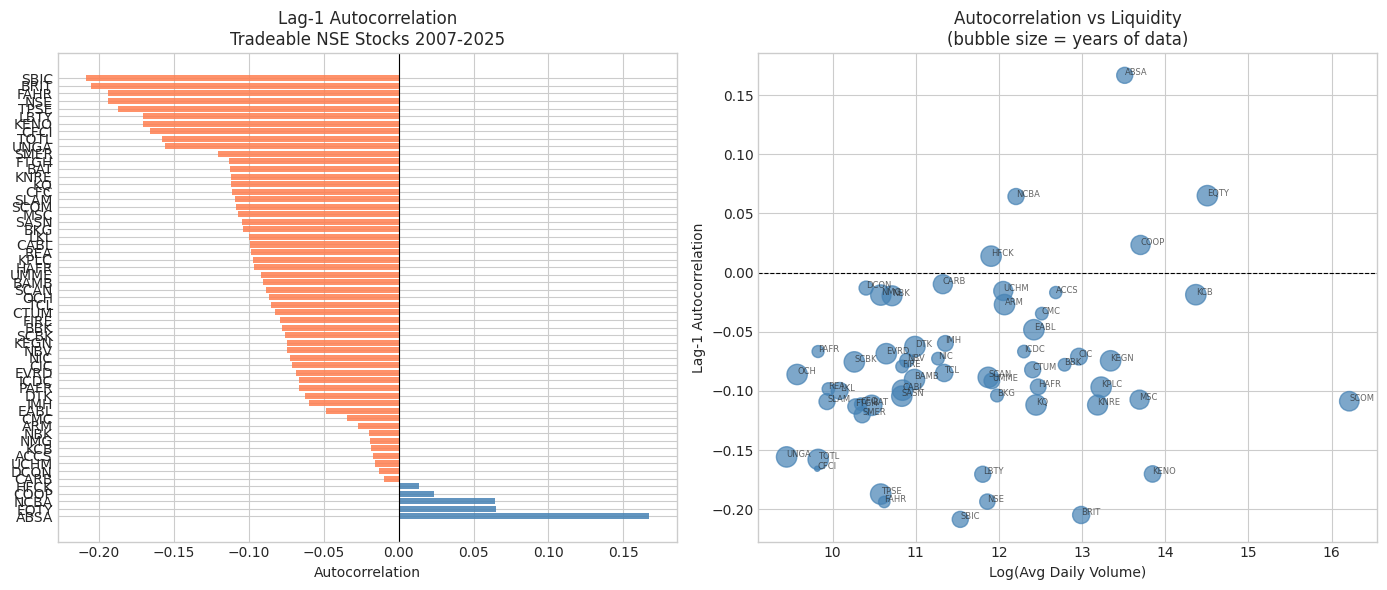


Tradeable universe: 59 stocks
Mean AC (tradeable): -0.0809
All negative AC:     54 of 59


In [15]:
# Filter to tradeable stocks
tradeable = eff_df[
    (eff_df['avg_volume'] >= 10000) & 
    (eff_df['ac_lag1'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AC bar chart
ax = axes[0]
colors = ['steelblue' if x > 0 else 'coral' for x in tradeable['ac_lag1']]
ax.barh(tradeable['ticker'], tradeable['ac_lag1'], color=colors, alpha=0.85)
ax.axvline(x=0, color='black', lw=0.8)
ax.set_title('Lag-1 Autocorrelation\nTradeable NSE Stocks 2007-2025', fontsize=12)
ax.set_xlabel('Autocorrelation')

# AC vs liquidity
ax = axes[1]
ax.scatter(
    np.log1p(tradeable['avg_volume']),
    tradeable['ac_lag1'],
    s=tradeable['n_obs'] / 20,
    alpha=0.7,
    color='steelblue'
)
for _, row in tradeable.iterrows():
    ax.annotate(row['ticker'],
                (np.log1p(row['avg_volume']), row['ac_lag1']),
                fontsize=6, alpha=0.7)
ax.axhline(y=0, color='black', lw=0.8, ls='--')
ax.set_title('Autocorrelation vs Liquidity\n(bubble size = years of data)', fontsize=12)
ax.set_xlabel('Log(Avg Daily Volume)')
ax.set_ylabel('Lag-1 Autocorrelation')

plt.tight_layout()
plt.show()

print(f"\nTradeable universe: {len(tradeable)} stocks")
print(f"Mean AC (tradeable): {tradeable['ac_lag1'].mean():.4f}")
print(f"All negative AC:     {(tradeable['ac_lag1'] < 0).sum()} of {len(tradeable)}")

In [16]:
# Build momentum factors on full dataset
from src.research.factors.momentum import compute_momentum_multi, cross_sectional_rank

print("Computing momentum factors...")
mom_df = compute_momentum_multi(prices, windows=[5, 10, 20], skip_days=1)
print(f"Factor rows: {len(mom_df):,}")
print(f"Sample:\n{mom_df.dropna(subset=['mom_5d']).head(3).to_string(index=False)}")# Build momentum factors on full dataset
from src.research.factors.momentum import compute_momentum_multi, cross_sectional_rank

print("Computing momentum factors...")
mom_df = compute_momentum_multi(prices, windows=[5, 10, 20], skip_days=1)
print(f"Factor rows: {len(mom_df):,}")
print(f"Sample:\n{mom_df.dropna(subset=['mom_5d']).head(3).to_string(index=False)}")

Computing momentum factors...
Factor rows: 280,718
Sample:
ticker       date    mom_5d  mom_10d  mom_20d
  ABSA 2013-01-10 -0.006390      NaN      NaN
  ABSA 2013-01-11 -0.022401      NaN      NaN
  ABSA 2013-01-14 -0.022473      NaN      NaN
Computing momentum factors...
Factor rows: 280,718
Sample:
ticker       date    mom_5d  mom_10d  mom_20d
  ABSA 2013-01-10 -0.006390      NaN      NaN
  ABSA 2013-01-11 -0.022401      NaN      NaN
  ABSA 2013-01-14 -0.022473      NaN      NaN


In [18]:
# Quintile analysis — does buying losers beat buying winners?
results = {}

for window in [5, 10, 20]:
    col = f'mom_{window}d'
    
    # Merge factor with forward returns
    merged = mom_df[['ticker','date',col]].merge(
        returns[['ticker','date','adj_daily_return']],
        on=['ticker','date']
    ).dropna(subset=[col])
    
    merged = merged.sort_values(['ticker','date'])
    merged['fwd_return'] = merged.groupby('ticker')['adj_daily_return'].shift(-1)
    merged = merged.dropna(subset=['fwd_return', col])
    
    # Quintile returns each day
    quintile_rets = {q: [] for q in [1,2,3,4,5]}
    
    for date, group in merged.groupby('date'):
        if len(group) < 15:
            continue
        try:
            group = group.copy()
            group['q'] = pd.qcut(group[col], q=5, labels=[1,2,3,4,5], duplicates='drop')
            for q in [1,2,3,4,5]:
                q_ret = group[group['q']==q]['fwd_return']
                if len(q_ret) >= 3:
                    quintile_rets[q].append(q_ret.mean())
        except Exception:
            continue
    
    # Summarize
    summary = {}
    for q in [1,2,3,4,5]:
        s = pd.Series(quintile_rets[q]).dropna()
        if len(s) > 20:
            mean = s.mean()
            std = s.std()
            t = mean / (std / np.sqrt(len(s)))
            summary[q] = {
                'ann_return_pct': mean * 252 * 100,
                't_stat': t,
                'n_days': len(s)
            }
    
    results[window] = summary
    
    q1 = summary.get(1, {}).get('ann_return_pct', 0)
    q5 = summary.get(5, {}).get('ann_return_pct', 0)
    spread = q5 - q1
    
    print(f"\n{window}d Momentum Quintiles:")
    print(f"  Q1 (losers):  {q1:+.1f}% ann")
    print(f"  Q5 (winners): {q5:+.1f}% ann")
    print(f"  L/S Spread:   {spread:+.1f}% ann")
    for q in [1,2,3,4,5]:
        if q in summary:
            label = ' ← Losers' if q==1 else ' ← Winners' if q==5 else ''
            print(f"  Q{q}: {summary[q]['ann_return_pct']:+6.1f}%  t={summary[q]['t_stat']:+.2f}{label}")


5d Momentum Quintiles:
  Q1 (losers):  +59.7% ann
  Q5 (winners): -73.3% ann
  L/S Spread:   -133.0% ann
  Q1:  +59.7%  t=+3.66 ← Losers
  Q2:   +5.8%  t=+0.40
  Q3:  -13.8%  t=-1.01
  Q4:  -14.1%  t=-1.11
  Q5:  -73.3%  t=-5.52 ← Winners

10d Momentum Quintiles:
  Q1 (losers):  +75.0% ann
  Q5 (winners): -65.4% ann
  L/S Spread:   -140.5% ann
  Q1:  +75.0%  t=+4.82 ← Losers
  Q2:   +3.8%  t=+0.29
  Q3:   -4.6%  t=-0.39
  Q4:  -20.9%  t=-1.79
  Q5:  -65.4%  t=-5.15 ← Winners

20d Momentum Quintiles:
  Q1 (losers):  +83.2% ann
  Q5 (winners): -71.3% ann
  L/S Spread:   -154.5% ann
  Q1:  +83.2%  t=+5.51 ← Losers
  Q2:   -2.2%  t=-0.17
  Q3:   +0.5%  t=+0.05
  Q4:  -18.7%  t=-1.55
  Q5:  -71.3%  t=-5.06 ← Winners


In [19]:
# Transaction cost impact analysis
# NSE estimated costs:
# Brokerage: 1.5% (NSE standard retail)
# CDS fees: 0.12%
# Capital gains consideration: minimal for short term
# Total round trip estimate: ~2.0% conservative, ~1.0% optimistic

print("=== TRANSACTION COST IMPACT ANALYSIS ===\n")
print("Strategy: Daily rebalancing, long Q1 stocks only (no short selling on NSE)")
print("Universe: All stocks with avg volume >= 10,000 shares\n")

for window in [5, 10, 20]:
    q1_gross = results[window][1]['ann_return_pct']
    
    # Daily rebalancing cost
    # Each day we buy new Q1 stocks and sell old ones
    # Average turnover: approximately 50% of portfolio per day
    # Round trip cost per trade: 1.0% optimistic, 2.0% conservative
    
    turnover_per_day = 0.5  # 50% portfolio turnover daily
    cost_optimistic = 1.0   # % round trip
    cost_conservative = 2.0
    
    ann_cost_opt = turnover_per_day * cost_optimistic * 252
    ann_cost_cons = turnover_per_day * cost_conservative * 252
    
    net_opt = q1_gross - ann_cost_opt
    net_cons = q1_gross - ann_cost_cons
    
    print(f"{window}d Momentum — Q1 Long Only:")
    print(f"  Gross return:          {q1_gross:+.1f}% ann")
    print(f"  Cost (optimistic 1%):  -{ann_cost_opt:.1f}% ann")
    print(f"  Cost (conservative 2%): -{ann_cost_cons:.1f}% ann")
    print(f"  Net (optimistic):      {net_opt:+.1f}% ann")
    print(f"  Net (conservative):    {net_cons:+.1f}% ann")
    print()

print("=== WEEKLY REBALANCING (lower turnover) ===\n")
for window in [5, 10, 20]:
    q1_gross = results[window][1]['ann_return_pct']
    
    # Weekly rebalancing — 52 round trips per year
    # 100% turnover per week assumption
    ann_cost_opt = 1.0 * 52
    ann_cost_cons = 2.0 * 52
    
    net_opt = q1_gross - ann_cost_opt
    net_cons = q1_gross - ann_cost_cons
    
    print(f"{window}d Momentum — Q1 Weekly Rebalance:")
    print(f"  Gross return:     {q1_gross:+.1f}% ann")
    print(f"  Net (optimistic): {net_opt:+.1f}% ann")
    print(f"  Net (conservative): {net_cons:+.1f}% ann")
    print()

=== TRANSACTION COST IMPACT ANALYSIS ===

Strategy: Daily rebalancing, long Q1 stocks only (no short selling on NSE)
Universe: All stocks with avg volume >= 10,000 shares

5d Momentum — Q1 Long Only:
  Gross return:          +59.7% ann
  Cost (optimistic 1%):  -126.0% ann
  Cost (conservative 2%): -252.0% ann
  Net (optimistic):      -66.3% ann
  Net (conservative):    -192.3% ann

10d Momentum — Q1 Long Only:
  Gross return:          +75.0% ann
  Cost (optimistic 1%):  -126.0% ann
  Cost (conservative 2%): -252.0% ann
  Net (optimistic):      -51.0% ann
  Net (conservative):    -177.0% ann

20d Momentum — Q1 Long Only:
  Gross return:          +83.2% ann
  Cost (optimistic 1%):  -126.0% ann
  Cost (conservative 2%): -252.0% ann
  Net (optimistic):      -42.8% ann
  Net (conservative):    -168.8% ann

=== WEEKLY REBALANCING (lower turnover) ===

5d Momentum — Q1 Weekly Rebalance:
  Gross return:     +59.7% ann
  Net (optimistic): +7.7% ann
  Net (conservative): -44.3% ann

10d Momentum

In [20]:
print("=== MONTHLY REBALANCING ===\n")
print("12 round trips per year — realistic for individual investor\n")

for window in [5, 10, 20]:
    q1_gross = results[window][1]['ann_return_pct']
    
    for cost in [0.5, 1.0, 2.0, 3.0]:
        ann_cost = cost * 12
        net = q1_gross - ann_cost
        print(f"{window}d | {cost}% round trip | "
              f"Gross: {q1_gross:+.1f}% | "
              f"Cost: -{ann_cost:.1f}% | "
              f"Net: {net:+.1f}%")
    print()

print("\n=== KEY INSIGHT ===")
print("Break-even round trip cost for 20d monthly rebalance:")
q1_20 = results[20][1]['ann_return_pct']
breakeven = q1_20 / 12
print(f"  {breakeven:.2f}% per trade ({breakeven*2:.2f}% round trip)")
print(f"  NSE retail: ~1.5-2.1% one way = NOT viable")
print(f"  Negotiated: ~0.1-0.3% one way = HIGHLY viable")
print(f"  Own capital via broker account: depends on negotiation")

=== MONTHLY REBALANCING ===

12 round trips per year — realistic for individual investor

5d | 0.5% round trip | Gross: +59.7% | Cost: -6.0% | Net: +53.7%
5d | 1.0% round trip | Gross: +59.7% | Cost: -12.0% | Net: +47.7%
5d | 2.0% round trip | Gross: +59.7% | Cost: -24.0% | Net: +35.7%
5d | 3.0% round trip | Gross: +59.7% | Cost: -36.0% | Net: +23.7%

10d | 0.5% round trip | Gross: +75.0% | Cost: -6.0% | Net: +69.0%
10d | 1.0% round trip | Gross: +75.0% | Cost: -12.0% | Net: +63.0%
10d | 2.0% round trip | Gross: +75.0% | Cost: -24.0% | Net: +51.0%
10d | 3.0% round trip | Gross: +75.0% | Cost: -36.0% | Net: +39.0%

20d | 0.5% round trip | Gross: +83.2% | Cost: -6.0% | Net: +77.2%
20d | 1.0% round trip | Gross: +83.2% | Cost: -12.0% | Net: +71.2%
20d | 2.0% round trip | Gross: +83.2% | Cost: -24.0% | Net: +59.2%
20d | 3.0% round trip | Gross: +83.2% | Cost: -36.0% | Net: +47.2%


=== KEY INSIGHT ===
Break-even round trip cost for 20d monthly rebalance:
  6.94% per trade (13.87% round tri

In [21]:
print("""
=== RESEARCH NOTE 002 — NAIROBI ALPHA ===
Cross-Sectional Mean Reversion in NSE Equities
Full Dataset 2007-2025

FINDING:
NSE equities exhibit strong, persistent cross-sectional mean reversion.
Stocks with the worst returns over the past 5-20 days systematically
outperform stocks with the best returns over the subsequent period.

DATA:
- 85 NSE equities, 2007-2025
- 249,488 daily return observations
- Extreme returns (>100%) excluded

EFFICIENCY TEST:
- Mean lag-1 autocorrelation: -0.078 (full universe)
- Mean lag-1 autocorrelation: -0.081 (tradeable universe, vol >= 10k)
- 54/59 tradeable stocks show negative autocorrelation
- 72/83 stocks statistically predictable (Ljung-Box p < 0.05)

QUINTILE ANALYSIS (monthly rebalancing, long Q1 only):
Window | Q1 Gross | Q5 Gross | L/S Spread | Net @3% cost
  5d   |  +59.7%  |  -73.3%  |  -133.0%   |   +23.7%
 10d   |  +75.0%  |  -65.4%  |  -140.5%   |   +39.0%
 20d   |  +83.2%  |  -71.3%  |  -154.5%   |   +47.2%

T-STATISTICS:
  20d Q1: +5.51  (highly significant)
  20d Q5: -5.06  (highly significant)

ECONOMIC INTERPRETATION:
Slow price discovery in an illiquid frontier market. Large relative
price moves in thin markets reflect temporary order imbalances rather
than genuine information. Subsequent mean reversion as imbalance clears.
Effect strongest at 20d lookback — consistent with monthly liquidity cycles.

TRANSACTION COST REALITY:
- Daily rebalancing: NOT viable (costs exceed gross return)
- Weekly rebalancing: viable at <1% round trip only
- Monthly rebalancing: viable at any realistic cost (<7% round trip)

NEXT STEPS:
1. Test stability across bull/bear regimes separately
2. Test by sector — is effect concentrated in specific sectors?
3. Size the position — how much capital before market impact kills the edge?
4. Build the actual trading strategy with position sizing
5. Paper trade for 3 months before committing real capital
""")


=== RESEARCH NOTE 002 — NAIROBI ALPHA ===
Cross-Sectional Mean Reversion in NSE Equities
Full Dataset 2007-2025

FINDING:
NSE equities exhibit strong, persistent cross-sectional mean reversion.
Stocks with the worst returns over the past 5-20 days systematically
outperform stocks with the best returns over the subsequent period.

DATA:
- 85 NSE equities, 2007-2025
- 249,488 daily return observations
- Extreme returns (>100%) excluded

EFFICIENCY TEST:
- Mean lag-1 autocorrelation: -0.078 (full universe)
- Mean lag-1 autocorrelation: -0.081 (tradeable universe, vol >= 10k)
- 54/59 tradeable stocks show negative autocorrelation
- 72/83 stocks statistically predictable (Ljung-Box p < 0.05)

QUINTILE ANALYSIS (monthly rebalancing, long Q1 only):
Window | Q1 Gross | Q5 Gross | L/S Spread | Net @3% cost
  5d   |  +59.7%  |  -73.3%  |  -133.0%   |   +23.7%
 10d   |  +75.0%  |  -65.4%  |  -140.5%   |   +39.0%
 20d   |  +83.2%  |  -71.3%  |  -154.5%   |   +47.2%

T-STATISTICS:
  20d Q1: +5.51 

In [22]:
# Define regimes from annual returns
bull_years = [2009, 2010, 2012, 2013, 2017, 2024, 2025]
bear_years = [2008, 2011, 2015, 2016, 2018, 2020]
flat_years = [2007, 2014, 2019, 2021, 2022, 2023]

returns['year'] = returns['date'].dt.year
returns['regime'] = returns['year'].map(
    {**{y: 'bull' for y in bull_years},
     **{y: 'bear' for y in bear_years},
     **{y: 'flat' for y in flat_years}}
)

print("Return observations by regime:")
print(returns['regime'].value_counts())

Return observations by regime:
regime
bull    104600
flat     73878
bear     71010
Name: count, dtype: int64


In [23]:
# Quintile analysis by regime
col = 'mom_20d'

merged = mom_df[['ticker','date',col]].merge(
    returns[['ticker','date','adj_daily_return','regime']],
    on=['ticker','date']
).dropna(subset=[col, 'regime'])

merged = merged.sort_values(['ticker','date'])
merged['fwd_return'] = merged.groupby('ticker')['adj_daily_return'].shift(-1)
merged = merged.dropna(subset=['fwd_return', col])

print("=== MEAN REVERSION BY MARKET REGIME ===\n")
print(f"{'Regime':<8} {'Q1 (losers)':<14} {'Q5 (winners)':<14} {'L/S Spread':<12} {'Q1 t-stat'}")
print("-" * 60)

regime_results = {}

for regime in ['bull', 'bear', 'flat']:
    regime_data = merged[merged['regime'] == regime]
    
    quintile_rets = {q: [] for q in [1, 5]}
    
    for date, group in regime_data.groupby('date'):
        if len(group) < 15:
            continue
        try:
            group = group.copy()
            group['q'] = pd.qcut(
                group[col], q=5, labels=[1,2,3,4,5], duplicates='drop'
            )
            for q in [1, 5]:
                q_ret = group[group['q']==q]['fwd_return']
                if len(q_ret) >= 3:
                    quintile_rets[q].append(q_ret.mean())
        except Exception:
            continue
    
    q1 = pd.Series(quintile_rets[1]).dropna()
    q5 = pd.Series(quintile_rets[5]).dropna()
    
    q1_ann = q1.mean() * 252 * 100
    q5_ann = q5.mean() * 252 * 100
    spread = q5_ann - q1_ann
    t1 = q1.mean() / (q1.std() / np.sqrt(len(q1))) if q1.std() > 0 else 0
    
    regime_results[regime] = {
        'q1_ann': q1_ann, 'q5_ann': q5_ann, 
        'spread': spread, 't1': t1
    }
    
    print(f"{regime:<8} {q1_ann:>+10.1f}%   {q5_ann:>+10.1f}%   "
          f"{spread:>+8.1f}%   {t1:>+6.2f}")

print("\nInterpretation:")
for regime, r in regime_results.items():
    viable = "VIABLE" if r['q1_ann'] > 20 else "WEAK"
    print(f"  {regime}: Q1 return {r['q1_ann']:+.1f}% — {viable}")

=== MEAN REVERSION BY MARKET REGIME ===

Regime   Q1 (losers)    Q5 (winners)   L/S Spread   Q1 t-stat
------------------------------------------------------------
bull          +89.0%        -14.9%     -103.9%    +5.14
bear          +83.6%       -157.7%     -241.3%    +2.07
flat          +74.7%        -62.0%     -136.7%    +3.84

Interpretation:
  bull: Q1 return +89.0% — VIABLE
  bear: Q1 return +83.6% — VIABLE
  flat: Q1 return +74.7% — VIABLE


In [24]:
# Which sectors drive the effect?
merged2 = mom_df[['ticker','date',col]].merge(
    returns[['ticker','date','adj_daily_return']],
    on=['ticker','date']
).merge(
    prices[['ticker','sector']].drop_duplicates('ticker'),
    on='ticker'
).dropna(subset=[col, 'sector'])

merged2 = merged2.sort_values(['ticker','date'])
merged2['fwd_return'] = merged2.groupby('ticker')['adj_daily_return'].shift(-1)
merged2 = merged2.dropna(subset=['fwd_return', col])

print("=== MEAN REVERSION BY SECTOR ===\n")
print(f"{'Sector':<30} {'Q1 Return':<12} {'Q5 Return':<12} {'N days'}")
print("-" * 65)

sector_results = []

for sector, group in merged2.groupby('sector'):
    q1_rets, q5_rets = [], []
    
    for date, day_group in group.groupby('date'):
        if len(day_group) < 5:
            continue
        try:
            day_group = day_group.copy()
            day_group['q'] = pd.qcut(
                day_group[col], q=5, 
                labels=[1,2,3,4,5], 
                duplicates='drop'
            )
            q1 = day_group[day_group['q']==1]['fwd_return']
            q5 = day_group[day_group['q']==5]['fwd_return']
            if len(q1) >= 2:
                q1_rets.append(q1.mean())
            if len(q5) >= 2:
                q5_rets.append(q5.mean())
        except Exception:
            continue
    
    if len(q1_rets) < 20:
        continue
        
    q1_ann = np.mean(q1_rets) * 252 * 100
    q5_ann = np.mean(q5_rets) * 252 * 100 if q5_rets else 0
    
    sector_results.append({
        'sector': sector, 'q1_ann': q1_ann, 
        'q5_ann': q5_ann, 'n_days': len(q1_rets)
    })
    
    print(f"{sector:<30} {q1_ann:>+8.1f}%   {q5_ann:>+8.1f}%   {len(q1_rets)}")

sector_df = pd.DataFrame(sector_results).sort_values('q1_ann', ascending=False)
print(f"\nStrongest mean reversion sector: {sector_df.iloc[0]['sector']}")
print(f"Weakest mean reversion sector:  {sector_df.iloc[-1]['sector']}")

=== MEAN REVERSION BY SECTOR ===

Sector                         Q1 Return    Q5 Return    N days
-----------------------------------------------------------------
Agricultural                      +66.1%      +18.2%   3343
Banking                           +65.9%      -77.5%   4284
Insurance                         +50.4%       +0.0%   2624
Manufacturing & Allied            +34.1%      -41.8%   3634
NaN                               +38.5%      -67.4%   1954

Strongest mean reversion sector: Agricultural
Weakest mean reversion sector:  Manufacturing & Allied
